# Python Lesson 11: Singular and Non-singular Matrices

**Concept page:** `wiki/concepts/singular-and-non-singular-matrices.md` · **Area:** linear-algebra

**You will be able to:**
- test singularity by determinant, rank and condition number
- see singular matrices squash the plane
- connect to existence of the inverse

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. One question, many tests

In [2]:
def report(A):
    A=np.array(A,float)
    return dict(det=round(np.linalg.det(A),6), rank=np.linalg.matrix_rank(A), cond=np.linalg.cond(A))
for A in ([[1,1],[1,2]],[[1,1],[2,2]],[[0,0],[0,0]]):
    print(A, report(A))

[[1, 1], [1, 2]] {'det': np.float64(1.0), 'rank': np.int64(2), 'cond': np.float64(6.854101966249685)}
[[1, 1], [2, 2]] {'det': np.float64(0.0), 'rank': np.int64(1), 'cond': np.float64(2.2045408084588716e+16)}
[[0, 0], [0, 0]] {'det': np.float64(0.0), 'rank': np.int64(0), 'cond': np.float64(inf)}


## 2. Inverse exists only for non-singular matrices

In [3]:
try: print(np.linalg.inv([[1,1],[1,2]]))
except np.linalg.LinAlgError as e: print(e)
try: print(np.linalg.inv([[1,1],[2,2]]))
except np.linalg.LinAlgError as e: print("singular ->", e)

[[ 2. -1.]
 [-1.  1.]]
singular -> Singular matrix


## 3. Near-singular matrices are numerically dangerous

In [4]:
A=np.array([[1,1],[1,1+1e-10]]); print(np.linalg.cond(A))

39999965677.40396


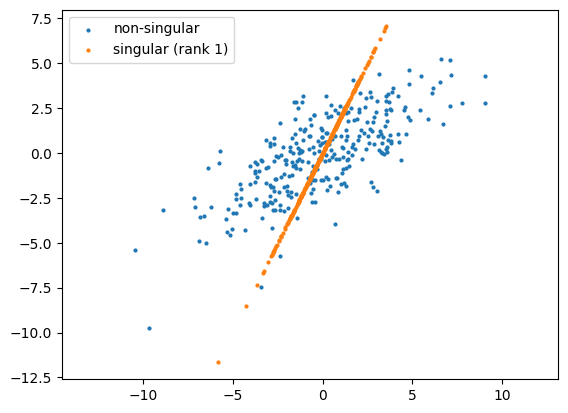

In [5]:
pts=np.random.default_rng(0).normal(size=(2,300))
for A,t in (([[3,1],[1,2]],"non-singular"),([[1,1],[2,2]],"singular (rank 1)")):
    q=np.array(A,float)@pts; plt.scatter(q[0],q[1],s=4,label=t)
plt.legend(); plt.axis('equal'); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 11 basic: a 2×2 matrix with determinant 0 has no inverse (the book's P = [[−2,3],[−4,6]], |P| = −12+12 = 0).

In [6]:
print(np.linalg.det(np.array([[-2,3],[-4,6]])))

0.0


## Exercises

**Exercise 1.** Write `is_singular(A)` using rank and test it on 3 matrices.

In [7]:
# your code here

**Exercise 2.** The matrix [[1,2,3],[4,5,6],[7,8,9]] is singular. Show det≈0 and find a dependency among rows.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
is_singular=lambda A: np.linalg.matrix_rank(np.array(A,float))<len(A)
assert is_singular([[1,2],[2,4]]) and not is_singular([[1,0],[0,1]])

In [10]:
# Solution 2
M=np.array([[1,2,3],[4,5,6],[7,8,9]],float); print(np.linalg.det(M)); assert abs(np.linalg.det(M))<1e-9; assert np.allclose(M[0]+M[2],2*M[1])

-9.51619735392994e-16
